# *Saudi Arabia Job Market*

In this notebook, I explored dataset from Jadarat, to analyze job posting in Saudi Arabia.
 The goal was to cover job trends , in- demand role , top hiring cities , contract type and salary distribution.


#1.**Setup & Data loading:**

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Download latest version
path = kagglehub.dataset_download("shaykhaaldawsari/jadarat-cleaned-data-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'jadarat-cleaned-data-csv' dataset.
Path to dataset files: /kaggle/input/jadarat-cleaned-data-csv


In [2]:
# Set the path to the file you'd like to load
file_path = "processed_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shaykhaaldawsari/jadarat-cleaned-data-csv",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("\nData loaded successfully!")

Using Colab cache for faster access to the 'jadarat-cleaned-data-csv' dataset.

Data loaded successfully!


# 2. **Data cleaning & Check**

In [3]:
#Check dataset structure
print(f"Shape:{df.shape[0]:} row x {df.shape[1]} columns")
print("Columns:",df.columns.tolist())
df.head(3)

Shape:1470 row x 14 columns
Columns: ['job_title', 'job_date', 'comp_name', 'comp_type', 'comp_size', 'eco_activity', 'region', 'city', 'benefits', 'contract', 'positions', 'exper', 'gender', 'Salary']


,job_title,job_date,comp_name,comp_type,comp_size,eco_activity,region,city,benefits,contract,positions,exper,gender,Salary
0,Secretary,2022-10-01,مؤسسة دمك للمقاولات العامة,1,SB,Construction and Real Estate,Eastern,BUQAYQ,0,1,1,0,1,4000.0
1,Salesperson,2022-10-03,شركة محمد سراج عطار وأخويه,1,SB,Trade and Retail,Makkah,JEDDAH,1,1,3,0,0,4000.0
2,Receptionist,2022-10-08,مركز شار لطب الاسنان,1,MA,Trade and Retail,Makkah,JEDDAH,1,1,2,4,1,4000.0


In [4]:
#Check for missing value & duplicate
df.isnull().sum()

#the dataset shows no missing value.

,0
job_title,0
job_date,0
comp_name,0
comp_type,0
comp_size,0
eco_activity,0
region,0
city,0
benefits,0
contract,0


In [5]:
#Check for duplicate
print(f"Duplicates found : {df.duplicated().sum()}")
#Drop duplicates
df =df.drop_duplicates()
print(f"After removing duplicates :{len(df):,}")

Duplicates found : 83
After removing duplicates :1,387


In [6]:
# Convert salart to numeric
df['Salary'] = pd.to_numeric(df['Salary'])

# 3. **Exploratory Data Analysis**

In [7]:
#Overview dataset
print(f" Dataset Overview ")
print(f" Total jop posting: {len(df)} ")
print(f" Unique companies : {df['comp_name'].nunique():,} ")
print(f" Unique ciies     : {df['city'].nunique():,} ")
print(f" Unique job title : {df['job_title'].nunique():,} ")
if df['Salary'].notna().any():
    print(f" Ave salary(SAR)  : {df['Salary'].mean():,.0f}")

 Dataset Overview 
 Total jop posting: 1387 
 Unique companies : 886 
 Unique ciies     : 114 
 Unique job title : 44 
 Ave salary(SAR)  : 5,271


In [8]:
#Analyzing the most common job titles in Saudi Arabia
top_jobs= df['job_title'].value_counts().head(10)
print(top_jobs)

job_title
Analyst                     222
Salesperson                 188
Manager                     126
Accountant                  123
Technician                   97
Switchboard Operator         74
Engineer                     70
Receptionist                 62
Secretary                    47
Administrative Assistant     45
Name: count, dtype: int64


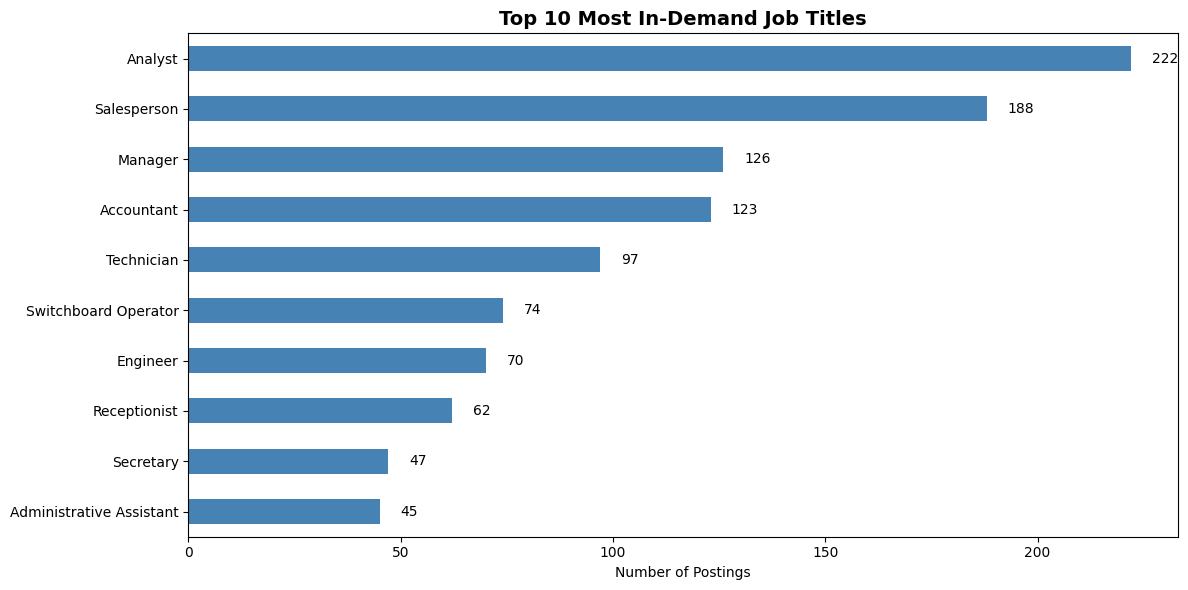


 Insight: the top job title is Analyst


In [9]:
# Bar chart for top jobs
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12,6))
top_jobs.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Most In-Demand Job Titles', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Postings')
ax.set_ylabel('')
for i, v in enumerate(top_jobs.sort_values()):
    ax.text(v + 5, i, str(v), va='center')
plt.tight_layout()
plt.show()

print("\n Insight: the top job title is",top_jobs.index[0] )

In [10]:
#Identifaying cities with highest number of job posting
top_cities =df['city'].value_counts().head(10)
print(top_cities)

city
AR RIYADH                  486
JEDDAH                     237
AD DAMMAM                   77
MAKKAH AL MUKARRAMAH        68
AL MADINAH AL MUNAWARAH     50
AL KHOBAR                   50
ABA ASLAB                   44
AL BAHA                     20
HAIL                        17
AL KHARJ                    16
Name: count, dtype: int64


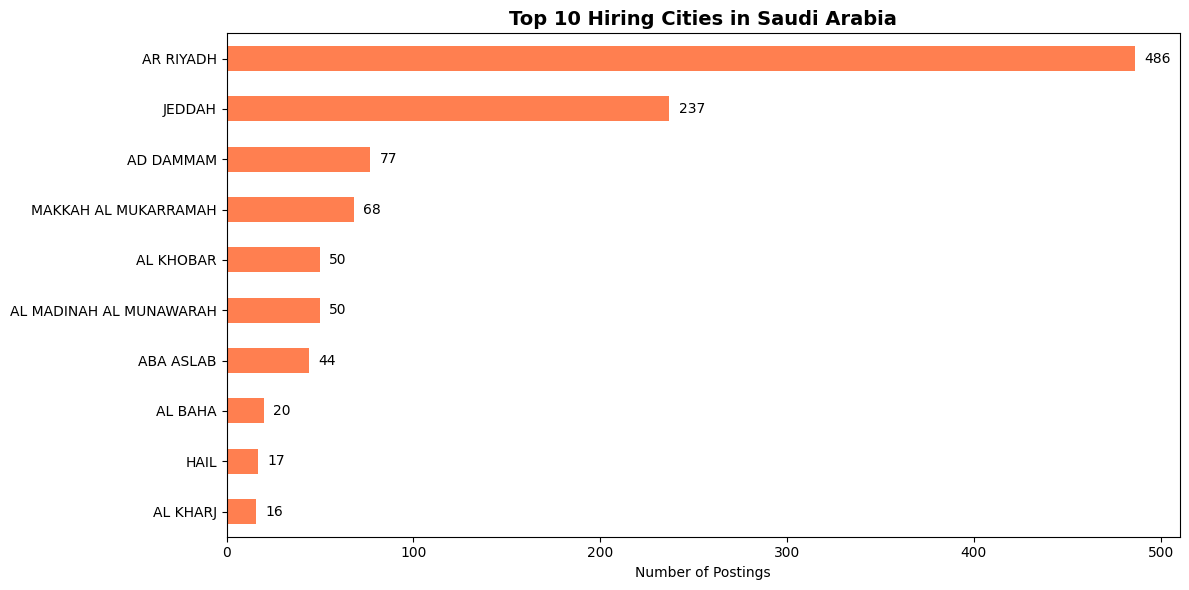


 Insight: the city with the highest job opportunities is AR RIYADH dominates with 486 postings


In [11]:
# the bar chart for top cities
fig, ax = plt.subplots(figsize=(12, 6))
top_cities.sort_values().plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 10 Hiring Cities in Saudi Arabia', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Postings')
ax.set_ylabel('')
for i, v in enumerate(top_cities.sort_values()):
    ax.text(v + 5, i, str(v), va='center')
plt.tight_layout()
plt.show()

print(f"\n Insight: the city with the highest job opportunities is {top_cities.index[0]} dominates with {top_cities.iloc[0]:,} postings" )

In [12]:
#Explore contract type:
contract = df['contract'].value_counts()
print(contract)
#1- for full time contracrt , 0 for part time

contract
1    1365
0      22
Name: count, dtype: int64


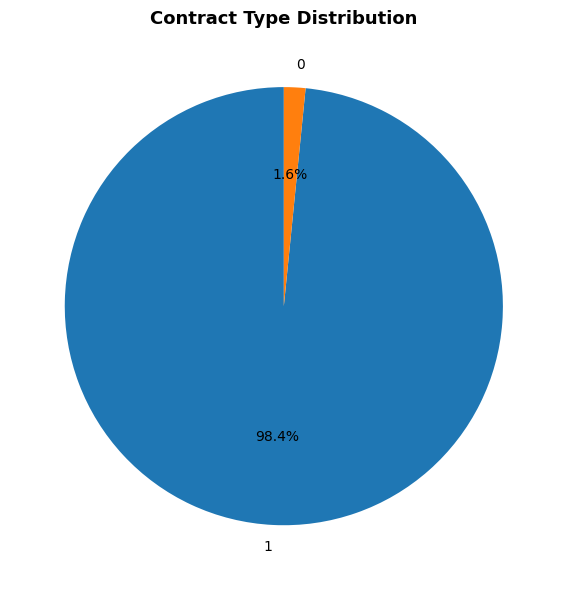


Insight : The majority of job posting belong to one contract tyoe, the remaining contract types represent a smaaler share of thr job market.


In [13]:
#pie chart reprecentation for type of contract
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.pie(contract, labels=contract.index , autopct='%1.1f%%',
       startangle=90 )


ax1.set_title("Contract Type Distribution", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


print(f"\nInsight : The majority of job posting belong to one contract tyoe, the remaining contract types represent a smaaler share of thr job market.")


In [14]:
#Salary distribiution
salary_data = df['Salary'].dropna()
print(salary_data.head(5))


0    4000.0
1    4000.0
2    4000.0
3    4000.0
4    5000.0
Name: Salary, dtype: float64


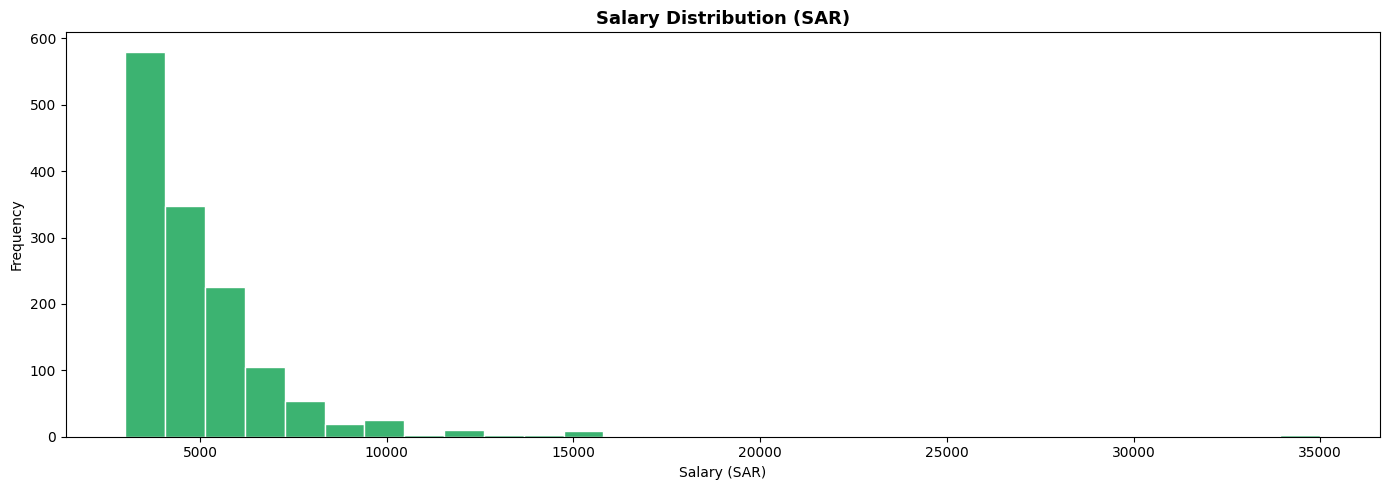


Salary Stats:
count     1387.0
mean      5271.0
std       2315.0
min       3000.0
25%       4000.0
50%       4500.0
75%       6000.0
max      35000.0
Name: Salary, dtype: float64


In [15]:
#Bar chart for salary dist
salary_data = df['Salary']

if len(salary_data)>0:
    fig,axes = plt.subplots(figsize=(14,5))

    salary_data.plot(kind='hist', bins=30, axes=axes, color='mediumseagreen', edgecolor='white')

    axes.set_title('Salary Distribution (SAR)', fontsize=13, fontweight='bold')
    axes.set_xlabel('Salary (SAR)')

    mean_salary = salary_data.mean()
    ax.axvline(mean_salary , color='red' , linestyle='--' , label=f'mean{mean_salary:,.0f}')
    ax.legend()


    plt.tight_layout()
    plt.show()

    print(f"\nSalary Stats:")
    print(salary_data.describe().round(0))
else:
    print("No salary data available after cleaning.")


In [16]:
#filltring the dataset to foucs on technology-related job

tech_keywords = [
    r'\bdata scientist\b',
    r'\bdata analyst\b',
    r'\bdata engineer\b',
    r'\bsoftware\b',
    r'\bdeveloper\b',
    r'\bprogrammer\b',
    r'\bcyber\b',
    r'\bcloud\b',
    r'\bdevops\b',
    r'\bnetwork engineer\b',
    r'\bsystems engineer\b',
    r'\binfrastructure\b',
    r'\bmachine learning\b',
    r'\bdeep learning\b',
    r'\bartificial intelligence\b',
    r'\bit support\b',
    r'\bit specialist\b',
    r'\bit manager\b',
    r'\binformation technology\b',
    r'\bfull.?stack\b',
    r'\bback.?end\b',
    r'\bfront.?end\b',
    r'\bpython\b',
    r'\bjava\b',
    r'\bsql\b',
    r'\bdba\b',
    r'\bsap\b',
    r'\berp\b',
    r'\bmlops\b',
]

pattern = '|'.join(tech_keywords)

df['is_tech_job'] = (
    df['job_title']
    .str.lower()
    .str.contains(pattern, na=False, regex=True)
    .astype(int)
)

tech_count = df['is_tech_job'].sum()
tech_pct   = df['is_tech_job'].mean() * 100

print(f"Tech jobs     : {tech_count:,}  ({tech_pct:.1f}%)")
print(f"Non-tech jobs : {len(df) - tech_count:,}  ({100 - tech_pct:.1f}%)")



Tech jobs     : 14  (1.0%)
Non-tech jobs : 1,373  (99.0%)


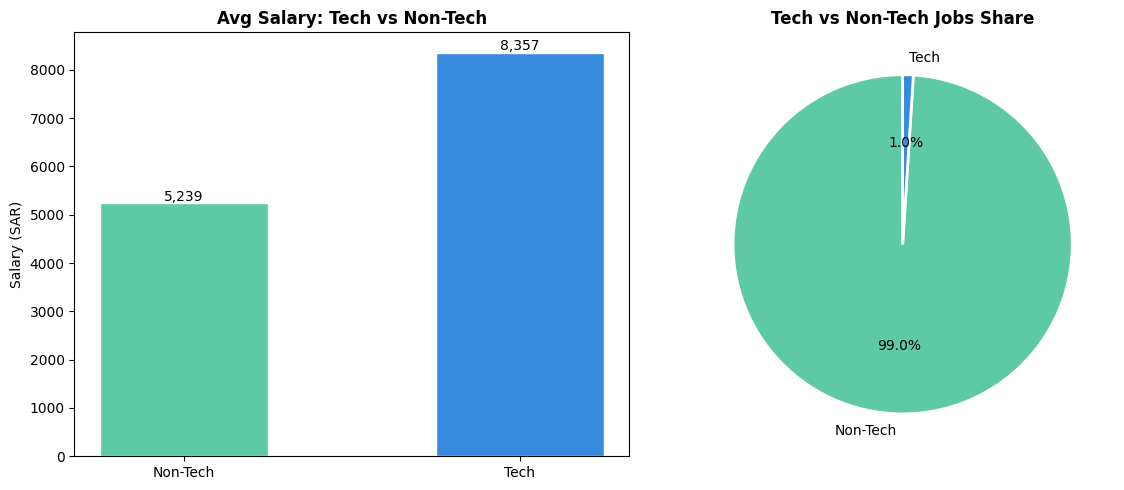


Insight: Tech jobs play a significant role in the Saudi job market, reflecting the Kingdom’s Vision 2030 and growing demand for digital skills.


In [17]:
tech_df = df[df['is_tech_job'] == 1]
nontech_df = df[df['is_tech_job'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#  Average Salary
salary_comp = {
    'Non-Tech': nontech_df['Salary'].mean(),
    'Tech': tech_df['Salary'].mean()
}

colors = ['#5DCAA5', '#378ADD']

axes[0].bar(
    salary_comp.keys(),
    salary_comp.values(),
    color=colors,
    edgecolor='white',
    width=0.5
)

axes[0].set_title('Avg Salary: Tech vs Non-Tech', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Salary (SAR)')

for i, (k, v) in enumerate(salary_comp.items()):
    axes[0].text(i, v + 50, f'{v:,.0f}', ha='center', fontsize=10)

#  Distribution
counts = df['is_tech_job'].map({0: 'Non-Tech', 1: 'Tech'}).value_counts()

axes[1].pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

axes[1].set_title('Tech vs Non-Tech Jobs Share', fontsize=12, fontweight='bold')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

diff = salary_comp['Tech'] - salary_comp['Non-Tech']

print(
    "\nInsight: Tech jobs play a significant role in the Saudi job market, "
    "reflecting the Kingdom’s Vision 2030 and growing demand for digital skills."
)

# 4. **Streamlit**

In [18]:
!pip install streamlit pyngrok kagglehub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 77.9 MB/s eta 0:00:00


In [39]:
%%writefile app.py
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
import kagglehub


TECH_PATTERN = '|'.join([
    r'\bdata scientist\b', r'\bdata analyst\b', r'\bdata engineer\b',
    r'\bsoftware\b', r'\bdeveloper\b', r'\bprogrammer\b',
    r'\bcyber\b', r'\bcloud\b', r'\bdevops\b',
    r'\bnetwork engineer\b', r'\bsystems engineer\b', r'\binfrastructure\b',
    r'\bmachine learning\b', r'\bdeep learning\b', r'\bartificial intelligence\b',
    r'\bit support\b', r'\bit specialist\b', r'\bit manager\b',
    r'\binformation technology\b', r'\bfull[- ]?stack\b',
    r'\bback[- ]?end\b', r'\bfront[- ]?end\b',
    r'\bpython\b', r'\bjava\b', r'\bsql\b',
    r'\bdba\b', r'\bsap\b', r'\berp\b', r'\bmlops\b'
])

# ── Palette & style ───────────────────────────────────────────────────────────
PRIMARY   = "#1B4F72"
SECONDARY = "#2E86C1"
ACCENT1   = "#28B463"
ACCENT2   = "#E67E22"
ACCENT3   = "#C0392B"
BG_CARD   = "#F4F6F8"

COLORS_BAR  = [PRIMARY, SECONDARY, ACCENT1, ACCENT2, "#8E44AD",
               "#17A589", "#D4AC0D", "#CB4335", "#1A5276", "#117A65"]

def style_fig(fig, ax):
    """Apply consistent styling to every matplotlib figure."""
    fig.patch.set_facecolor("white")
    ax.set_facecolor("#FAFAFA")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.tick_params(colors="#444444", labelsize=10)
    ax.xaxis.label.set_color("#444444")
    ax.yaxis.label.set_color("#444444")
    ax.title.set_color("#1B2631")

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(page_title="Saudi Job Market", layout="wide", page_icon="🇸🇦")

# ── Custom CSS ────────────────────────────────────────────────────────────────
st.markdown("""
<style>
/* General font */
html, body, [class*="css"] { font-family: 'Segoe UI', sans-serif; }

/* Page background */
.main { background-color: #F0F4F8; }

/* Sidebar */
section[data-testid="stSidebar"] {
    background: linear-gradient(160deg, #1B4F72 0%, #2E86C1 100%);
}
section[data-testid="stSidebar"] * { color: #FFFFFF !important; }
section[data-testid="stSidebar"] .stSelectbox label,
section[data-testid="stSidebar"] .stRadio label { color: #FFFFFF !important; }

/* Metric cards */
[data-testid="metric-container"] {
    background: #FFFFFF;
    border-radius: 12px;
    padding: 16px 20px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.08);
    border-left: 4px solid #2E86C1;
}
[data-testid="stMetricLabel"]  { color: #666666 !important; font-size: 13px; }
[data-testid="stMetricValue"]  { color: #1B4F72 !important; font-size: 26px; font-weight: 700; }

/* Section headers */
h2, h3 { color: #1B4F72 !important; }

/* Divider */
hr { border-color: #D5D8DC; }

/* DataFrame */
[data-testid="stDataFrame"] { border-radius: 10px; overflow: hidden; }
</style>
""", unsafe_allow_html=True)

# Header
st.markdown(
    f"""
    <div style="background:linear-gradient(135deg,{PRIMARY} 0%,{SECONDARY} 100%);
                border-radius:14px;padding:28px 32px;margin-bottom:24px;">
        <h1 style="color:#FFFFFF;margin:0;font-size:2rem;">Saudi Arabia Job Market Dashboard</h1>
        <p style="color:#AED6F1;margin:6px 0 0;">Exploratory Data Analysis — Jadarat Dataset</p>
    </div>
    """,
    unsafe_allow_html=True,
)

#  Data loading
@st.cache_data
def load_data():
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "shaykhaaldawsari/jadarat-cleaned-data-csv",
        "processed_dataset.csv"
    )
    df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce")
    df = df.drop_duplicates().dropna(subset=["job_title", "city"]).reset_index(drop=True)

    df["is_tech_job"] = (
        df["job_title"].str.lower()
        .str.contains(TECH_PATTERN, na=False, regex=True)
        .astype(int)
    )

    return df

with st.spinner("Loading dataset…"):
    df = load_data()

#  Sidebar
st.sidebar.markdown("## 🔍 Filters")

cities = ["All"] + sorted(df["city"].dropna().unique().tolist())
selected_city = st.sidebar.selectbox("City", cities, key="city_filter")

contracts = ["All"] + sorted(df["contract"].dropna().unique().tolist())
selected_contract = st.sidebar.selectbox("Contract Type", contracts, key="contract_filter")

job_type = st.sidebar.radio(
    "Job Type",
    ["All", "Tech Only", "Non-Tech Only"],
    key="job_type_filter"
)

#  Filtering
filtered = df.copy()

if selected_city != "All":
    filtered = filtered[filtered["city"] == selected_city]

if selected_contract != "All":
    filtered = filtered[filtered["contract"] == selected_contract]

if job_type == "Tech Only":
    filtered = filtered[filtered["is_tech_job"] == 1]
elif job_type == "Non-Tech Only":
    filtered = filtered[filtered["is_tech_job"] == 0]

# KPI row
st.markdown("### 📊 Key Metrics")
c1, c2, c3, c4 = st.columns(4)
c1.metric("Total Postings",  f"{len(filtered):,}")
c2.metric("Companies",       f"{filtered['comp_name'].nunique():,}")
c3.metric("Cities",          f"{filtered['city'].nunique()}")
avg_sal = filtered["Salary"].mean()
c4.metric("Avg Salary (SAR)", f"{avg_sal:,.0f}" if pd.notna(avg_sal) else "N/A")

st.divider()

#  Row 1 : Jobs & Cities
col1, col2 = st.columns(2)

with col1:
    st.markdown("### Top 10 Job Titles")
    top_jobs = filtered["job_title"].value_counts().head(10)

    if len(top_jobs) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        top_jobs.sort_values().plot(kind="barh", ax=ax, color=PRIMARY)
        ax.set_xlabel("Number of Postings", fontsize=11)
        for i, v in enumerate(top_jobs.sort_values()):
            ax.text(v + max(top_jobs)*0.01, i, f"{v:,}", va="center", fontsize=9, color="#333")
        style_fig(fig, ax)
        plt.tight_layout()
        st.pyplot(fig)
        plt.close(fig)
    else:
        st.info("No job titles found with current filters.")

with col2:
    st.markdown("### Top 10 Hiring Cities")
    top_cities = filtered["city"].value_counts().head(10)
    if len(top_cities) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        top_cities.sort_values().plot(kind="barh", ax=ax, color=ACCENT2)
        ax.set_xlabel("Number of Postings", fontsize=11)
        for i, v in enumerate(top_cities.sort_values()):
            ax.text(v + max(top_cities)*0.01, i, f"{v:,}", va="center", fontsize=9, color="#333")
        style_fig(fig, ax)
        plt.tight_layout()
        st.pyplot(fig)
        plt.close(fig)
    else:
        st.info("No cities found with current filters.")

st.divider()

#  Row 2 : Contract & Salary
col3, col4 = st.columns(2)

with col3:
    st.markdown("### 📄 Contract Type Distribution")
    contract = filtered["contract"].map({1: "Full Time", 0: "Part Time"}).value_counts()
    if len(contract) == 0:
        st.info("No contract data for current filters.")
    else:
     fig, ax = plt.subplots(figsize=(6, 5))
     wedge_props = {"edgecolor": "white", "linewidth": 2.5}
     ax.pie(
         contract,
         labels=contract.index,
         autopct="%1.1f%%",
         colors=[PRIMARY, ACCENT1],
         startangle=90,
         wedgeprops=wedge_props,
         textprops={"fontsize": 12}
     )
     ax.set_aspect("equal")
     fig.patch.set_facecolor("white")
     plt.tight_layout()
     st.pyplot(fig)
     plt.close(fig)

with col4:
    st.markdown("### Salary Distribution (SAR)")
    salary_data = filtered["Salary"].dropna()
    if len(salary_data) > 0:
        fig, ax = plt.subplots(figsize=(6, 5))
        salary_data.plot(kind="hist", bins=25, ax=ax, color=ACCENT1, edgecolor="white", alpha=0.85)
        ax.axvline(salary_data.mean(), color=ACCENT3, linestyle="--", linewidth=2,
                   label=f"Mean: {salary_data.mean():,.0f} SAR")
        ax.set_xlabel("Salary (SAR)", fontsize=11)
        ax.legend(fontsize=10)
        style_fig(fig, ax)
        plt.tight_layout()
        st.pyplot(fig)
        plt.close(fig)
    else:
        st.info("No salary data for current filters.")

st.divider()

#  Row 3 : Tech Analysis
st.markdown("### Tech Jobs Analysis")
col5, col6 = st.columns(2)

with col5:
    st.markdown("**Avg Salary: Tech vs Non-Tech**")
    salary_by_type = (
        filtered.groupby("is_tech_job")["Salary"]
        .mean()
        .rename({0: "Non-Tech", 1: "Tech"})
    )
    if len(salary_by_type) == 0:
        st.info("No salary data for current filters.")
    else:
     fig, ax = plt.subplots(figsize=(8, 5))
     salary_by_type.plot(kind="bar", ax=ax, color=[ACCENT1, SECONDARY], edgecolor="white", width=0.5)
     ax.set_xlabel("")
     ax.set_ylabel("Salary (SAR)", fontsize=11)
     ax.tick_params(axis="x", rotation=0)

     for i, v in enumerate(salary_by_type):
         ax.text(i, v + 80, f"{v:,.0f}", ha="center", fontsize=10, fontweight="bold", color="#1B2631")
     style_fig(fig, ax)
     plt.tight_layout()
     st.pyplot(fig)
     plt.close(fig)

with col6:
    st.markdown("**Top 10 Tech Job Titles**")
    top_tech = (
        filtered[filtered["is_tech_job"] == 1]["job_title"]
        .value_counts()
        .head(10)
    )
    if len(top_tech) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        top_tech.sort_values().plot(kind="barh", ax=ax, color=SECONDARY)
        ax.set_xlabel("Count", fontsize=11)
        for i, v in enumerate(top_tech.sort_values()):
            ax.text(v + max(top_tech)*0.01, i, f"{v:,}", va="center", fontsize=9, color="#333")
        style_fig(fig, ax)
        plt.tight_layout()
        st.pyplot(fig)
        plt.close(fig)
    else:
        st.info("No tech jobs found with current filters.")

st.divider()

#  Sample data table
st.markdown("### 📋 Sample Data")
st.dataframe(filtered.head(20), use_container_width=True)


Overwriting app.py


In [20]:
!ngrok config add-authtoken 3FVooPUFO1qyz7a39M6NbfYHJIa_6mRMK6URehsbpLaY3jJMZ

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [21]:
from pyngrok import ngrok
import subprocess, time

process = subprocess.Popen(['streamlit', 'run', 'app.py',
                            '--server.port', '8501',
                            '--server.headless', 'true'])
time.sleep(3)

#ngrok
public_url = ngrok.connect(8501)
ngrok.set_auth_token('3FVooPUFO1qyz7a39M6NbfYHJIa_6mRMK6URehsbpLaY3jJMZ')
print("URL:", public_url)

URL: NgrokTunnel: "https://undocked-figure-glucose.ngrok-free.dev" -> "http://localhost:8501"


#**5. The dataset Insights:**

- Riyadh and Jeddah have the highest number of job opportunities.
- The most common job title in the dataset is analyst, follow by Salesperson and Accountant.
- Salary increases with experience in most cases.
- Technology Jobs play a significant role in Saudi job market.(Jadarat)